# 06 — Robustness checks for the EGARCH-X / GARCHND results

Four diagnostic checks to decide whether the **κ=50% GARCHND** result is genuine
economic signal or an artifact:

1. **Out-of-sample forecasting** — does the model beat GARCH(1,1) at $h \in \{1,5,22\}$ on QLIKE/MSE? Diebold-Mariano test against the baseline.
2. **Placebo / regime-only test** — replace $\gamma\, d_3\, x^2_{t-1}$ with $\gamma\, d_3$ alone (regime intercept only) or with a shuffled placebo regressor. If the bare regime dummy captures the same fit improvement, the "news effect" is regime mean-reversion, not sentiment.
3. **SE stability across sigmoid sharpness $K$** — refit the κ=50% models at $K \in \{5, 10, 20, 50, \text{hard}\}$ and check robust sandwich SE + Hessian condition number. Stable across $K$ ⇒ significance is real; unstable ⇒ artifact of smoothing.
4. **Cluster count for κ=50% regime** — count distinct episodes (contiguous runs) where $\sigma^2_{t-1} \geq \kappa_{\text{high}}$. Few clusters ⇒ i.i.d. t-stats overstate evidence; need block-bootstrap or HAC with large bandwidth.

Models in focus: **GARCHND κ=50% Student-t** with $x \in \{\text{tone}, \text{log\_art\_growth}\}$. Benchmark: GARCH(1,1) Student-t.

In [25]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import norm
from statsmodels.tools.numdiff import approx_hess
from arch import arch_model
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

IN_PATH = '../CLEANED DATA/REMX_prices_sentiment_combined.xlsx'
df = (pd.read_excel(IN_PATH, parse_dates=['Date'])
        .sort_values('Date').reset_index(drop=True).set_index('Date'))
df['r'] = np.log(df['Close']/df['Close'].shift(1))
df['r'] = df['r'] - df['r'].mean()
df = df.dropna(subset=['r', 'tone_mean', 'log_art_growth', 'RV_rs']).copy()

# Scale to percent units for numerical stability (matches notebooks 03 / 04)
r_pct    = df['r'].values * 100.0
tone     = df['tone_mean'].values
log_artg = df['log_art_growth'].values
# RV_rs from Rogers–Satchell is in (log-return)^2 units. Convert to %^2/day
# so it lives on the same scale as σ²(GARCH) fitted on r_pct.
RV_pct2  = df['RV_rs'].values * 1e4

print(f'T = {len(df)} obs from {df.index.min().date()} to {df.index.max().date()}')
print(f'r_pct² mean = {(r_pct**2).mean():.3f}   RV_pct2 mean = {RV_pct2.mean():.3f}  '
      f'(should be in the same ballpark; ratio = {RV_pct2.mean()/(r_pct**2).mean():.2f})')

# κ thresholds (from notebook 03)
def ann_vol_to_daily_var(v_ann_pct):
    return (v_ann_pct / np.sqrt(252.0)) ** 2

KAPPA_LOW  = ann_vol_to_daily_var(30.0)
KAPPA_HIGH = ann_vol_to_daily_var(50.0)
print(f'κ_low  = {KAPPA_LOW:.4f}   κ_high = {KAPPA_HIGH:.4f}  (in %²/day)')

SMOOTH_K_DEFAULT = 20.0
PARAM_NAMES = ['omega', 'alpha', 'beta', 'gamma', 'nu']

T = 2765 obs from 2015-04-02 to 2026-03-31
r_pct² mean = 5.250   RV_pct2 mean = 2.050  (should be in the same ballpark; ratio = 0.39)
κ_low  = 3.5714   κ_high = 9.9206  (in %²/day)


## Shared MLE machinery

`garchnd_per_obs_ll` and `garchnd_fit` reproduce the recursion from notebook 03 with two configurable extras:

- `smooth_k` for the sigmoid sharpness, or `hard=True` for the indicator $d_3 = \mathbb{1}\{\sigma^2_{t-1} \geq \kappa\}$;
- `gamma_only=True` to fit the regime-intercept variant $\sigma^2_t = \omega + \alpha r^2_{t-1} + \beta \sigma^2_{t-1} + \gamma\, d_3$ (no $x^2$), used in Check 2.

Sandwich SEs and the Hessian condition number are computed at every fit so we can read them off in Check 3.

In [26]:
def _t_logpdf(z, nu):
    const = gammaln((nu+1)/2.0) - gammaln(nu/2.0) - 0.5*np.log(np.pi*(nu-2.0))
    return const - 0.5*(nu+1)*np.log1p(z**2/(nu-2.0))

def _d3(diff, smooth_k, hard):
    if hard:
        return 1.0 if diff >= 0 else 0.0
    return 1.0 / (1.0 + np.exp(-smooth_k * diff))

def garchnd_per_obs_ll(params, r, x, kappa, smooth_k=20.0, hard=False, gamma_only=False):
    omega, alpha, beta, gamma, nu = params
    n = len(r)
    sig2 = np.empty(n)
    sig2[0] = max(np.var(r), 1e-8)
    for t in range(1, n):
        d3 = _d3(sig2[t-1] - kappa, smooth_k, hard)
        news = gamma * d3 if gamma_only else gamma * d3 * x[t-1]**2
        s = omega + alpha*r[t-1]**2 + beta*sig2[t-1] + news
        sig2[t] = s if s > 1e-8 else 1e-8
    z = r / np.sqrt(sig2)
    ll_t = _t_logpdf(z, nu) - 0.5*np.log(sig2)
    return ll_t, sig2

def garchnd_fit(r, x, kappa, smooth_k=20.0, hard=False, gamma_only=False, x0=None,
                compute_se=True):
    if x0 is None:
        x0 = np.array([0.086, 0.089, 0.898, 0.01, 8.0])
    bounds = [(1e-8, None), (0.0, 0.999), (0.0, 0.999), (None, None), (2.05, 100.0)]

    def neg_ll(p, r, x):
        ll_t, _ = garchnd_per_obs_ll(p, r, x, kappa, smooth_k, hard, gamma_only)
        return -ll_t.sum()

    if hard:
        opt = minimize(neg_ll, x0, args=(r, x), method='Nelder-Mead',
                       options={'maxiter': 30000, 'xatol': 1e-7, 'fatol': 1e-7})
    else:
        opt = minimize(neg_ll, x0, args=(r, x), method='L-BFGS-B',
                       bounds=bounds, options={'maxiter': 5000})
        opt2 = minimize(neg_ll, opt.x, args=(r, x), method='Nelder-Mead',
                        options={'maxiter': 10000, 'xatol': 1e-7, 'fatol': 1e-7})
        if opt2.fun < opt.fun:
            opt = opt2

    theta = opt.x
    ll = -opt.fun

    se = np.full(5, np.nan)
    hess_cond = np.nan
    if compute_se:
        try:
            H = approx_hess(theta, neg_ll, args=(r, x))
            V_hess = np.linalg.inv(H)
            eps_fd = 1e-5
            n = len(r)
            G = np.empty((n, len(theta)))
            for i in range(len(theta)):
                up = theta.copy(); up[i] += eps_fd
                dn = theta.copy(); dn[i] -= eps_fd
                ll_up, _ = garchnd_per_obs_ll(up, r, x, kappa, smooth_k, hard, gamma_only)
                ll_dn, _ = garchnd_per_obs_ll(dn, r, x, kappa, smooth_k, hard, gamma_only)
                G[:, i] = (ll_up - ll_dn) / (2*eps_fd)
            V_robust = V_hess @ (G.T @ G) @ V_hess
            se = np.sqrt(np.abs(np.diag(V_robust)))
            eigs = np.linalg.eigvalsh(H)
            hess_cond = float(abs(eigs).max() / max(abs(eigs).min(), 1e-12))
        except Exception:
            pass

    _, sig2 = garchnd_per_obs_ll(theta, r, x, kappa, smooth_k, hard, gamma_only)
    aic = -2*ll + 2*len(theta)
    bic = -2*ll + len(theta)*np.log(len(r))
    return dict(theta=theta, ll=ll, aic=aic, bic=bic, se=se,
                hess_cond=hess_cond, sig2=sig2, converged=opt.success)

## Check 1 — Out-of-sample forecasting

In-sample fit through 2025-03-31 (matches the HAR split in notebook 05). OOS evaluation on the remaining trading days.

- **Target**: average realized variance $\overline{RV}_{t,t+h} = \frac{1}{h}\sum_{k=1}^{h} RV^{rs}_{t+k}$ (in %²/day), for $h \in \{1, 5, 22\}$.
- **Forecast**: iterated $h$-step ahead conditional variance. $\sigma^2_{t+1}|F_t$ uses observed lags $r_t, \sigma^2_t, x_t$; for $k \geq 2$ we use $\sigma^2_{t+k}|F_t = \omega + (\alpha+\beta)\, \sigma^2_{t+k-1}|F_t$ (future $x = 0$, so the $\gamma$ term zeroes out beyond the first step).
- **Losses**: **QLIKE** $L = \log(\sigma^2) + RV / \sigma^2$ (primary — robust to noisy RV proxies, Patton 2011) and **MSE** $L = (RV - \sigma^2)^2$ (secondary — biased by RV noise but reported for comparison).
- **Diebold-Mariano** vs the GARCH(1,1) baseline at each $h$, with Newey-West lag $= h-1$.

**Refit cadence**: single in-sample fit (static parameters during OOS). Periodic refit is straightforward to add but is unlikely to flip conclusions over a ~1-year window.

In [27]:
SPLIT_DATE = pd.Timestamp('2025-04-01')
oos_mask = df.index >= SPLIT_DATE
T = len(df)
T_in = int((~oos_mask).sum())
T_oos = int(oos_mask.sum())
HORIZONS = [1, 5, 22]
print(f'In-sample: {T_in} obs (through {df.index[T_in-1].date()})')
print(f'OOS: {T_oos} obs ({df.index[T_in].date()} -> {df.index[-1].date()})')

r_in    = r_pct[:T_in]
tone_in = tone[:T_in]
artg_in = log_artg[:T_in]

print('\nFitting GARCHND κ=50% Student-t (x = tone) on in-sample ...')
fit_tone = garchnd_fit(r_in, tone_in, KAPPA_HIGH)
print(f'  LL={fit_tone["ll"]:.2f}  AIC={fit_tone["aic"]:.2f}  converged={fit_tone["converged"]}')

print('Fitting GARCHND κ=50% Student-t (x = log_art_growth) on in-sample ...')
fit_artg = garchnd_fit(r_in, artg_in, KAPPA_HIGH)
print(f'  LL={fit_artg["ll"]:.2f}  AIC={fit_artg["aic"]:.2f}  converged={fit_artg["converged"]}')

print('Fitting GARCH(1,1) Student-t baseline (γ=0) on in-sample ...')
base = arch_model(pd.Series(r_in), mean='Zero', vol='GARCH', p=1, q=1, dist='t')
base_res = base.fit(disp='off')
base_theta = dict(
    omega = float(base_res.params['omega']),
    alpha = float(base_res.params['alpha[1]']),
    beta  = float(base_res.params['beta[1]']),
)
print(f'  LL={base_res.loglikelihood:.2f}  AIC={base_res.aic:.2f}')
print(f'  ω={base_theta["omega"]:.4f}  α={base_theta["alpha"]:.4f}  β={base_theta["beta"]:.4f}')

In-sample: 2514 obs (through 2025-03-31)
OOS: 251 obs (2025-04-01 -> 2026-03-31)

Fitting GARCHND κ=50% Student-t (x = tone) on in-sample ...
  LL=-5323.26  AIC=10656.51  converged=True
Fitting GARCHND κ=50% Student-t (x = log_art_growth) on in-sample ...
  LL=-5323.86  AIC=10657.72  converged=True
Fitting GARCH(1,1) Student-t baseline (γ=0) on in-sample ...
  LL=-5326.66  AIC=10661.31
  ω=0.0778  α=0.0764  β=0.9082


In [28]:
# ============================================================
# Check 1 (revised) — Rolling-window OOS forecasting
# OOS:    2023-01-03 -> 2026-03-31  (813 trading days)
# Window: 1,260 days, re-estimated daily
# Models: GARCH(1,1) Student-t baseline, GARCHND κ=50% (x=tone, x=log_art_growth)
# Proxies: RV_park (Parkinson) and RV_rs (Rogers–Satchell), both in %²/day
# Losses: HRMSE, QLIKE, RMSE, MAE
# Tests:  DM (two-sided) and Clark–West (one-sided) vs GARCH(1,1), NW lag = h-1
# ============================================================
import time
import scipy.stats as stats

OOS_START = pd.Timestamp('2023-01-03')
OOS_END   = pd.Timestamp('2026-03-31')
WINDOW    = 1260
HORIZONS  = [1, 5, 22]

RV_park_pct2 = df['RV_park'].values * 1e4
RV_rs_pct2   = df['RV_rs'].values   * 1e4
RV_PROXIES = {'Parkinson': RV_park_pct2, 'Rogers-Satchell': RV_rs_pct2}

dates_arr      = df.index
oos_target_pos = np.where((dates_arr >= OOS_START) & (dates_arr <= OOS_END))[0]
T_oos          = len(oos_target_pos)
print(f'OOS targets: {dates_arr[oos_target_pos[0]].date()} -> '
      f'{dates_arr[oos_target_pos[-1]].date()}  ({T_oos} days)')
print(f'Rolling window: {WINDOW} days, daily refit')

# ---- loss functions ----
def hrmse_loss(y, yhat):
    m = y != 0
    return float(np.sqrt(np.mean(((y[m] - yhat[m]) / y[m])**2)))
def qlike_loss(y, yhat): return float(np.mean(np.log(yhat) + y / yhat))
def rmse_loss(y, yhat):  return float(np.sqrt(np.mean((y - yhat)**2)))
def mae_loss(y, yhat):   return float(np.mean(np.abs(y - yhat)))

# ---- HAC variance of sample mean (Bartlett) ----
def nw_var_mean(x, lag):
    x = np.asarray(x, float); x = x - x.mean(); n = len(x)
    v = float(np.sum(x * x) / n)
    for l in range(1, lag + 1):
        w = 1.0 - l / (lag + 1.0)
        v += 2.0 * w * float(np.sum(x[l:] * x[:-l]) / n)
    return v / n

def dm_test_h(y, f_base, f_model, lag):
    """Two-sided DM on squared-loss differential. DM>0 ⇒ candidate has lower MSE."""
    d = (y - f_base) ** 2 - (y - f_model) ** 2
    var_d = nw_var_mean(d, lag)
    if var_d <= 0: return np.nan, np.nan
    dm = d.mean() / np.sqrt(var_d)
    return float(dm), float(2 * (1 - stats.norm.cdf(abs(dm))))

def clark_west(y, f_base, f_model, lag):
    """One-sided Clark–West for nested models. CW>0 ⇒ candidate beats baseline."""
    f = (y - f_base) ** 2 - ((y - f_model) ** 2 - (f_base - f_model) ** 2)
    var_f = nw_var_mean(f, lag)
    if var_f <= 0: return np.nan, np.nan
    t = f.mean() / np.sqrt(var_f)
    return float(t), float(1 - stats.norm.cdf(t))

# ---- fast GARCHND fit: L-BFGS-B only, no SE, warm-started ----
def garchnd_fit_fast(r, x, kappa, x0, smooth_k=SMOOTH_K_DEFAULT):
    bounds = [(1e-8, None), (0.0, 0.999), (0.0, 0.999), (None, None), (2.05, 100.0)]
    def neg_ll(p, r, x):
        ll_t, _ = garchnd_per_obs_ll(p, r, x, kappa, smooth_k, False, False)
        return -ll_t.sum()
    opt = minimize(neg_ll, x0, args=(r, x), method='L-BFGS-B',
                   bounds=bounds, options={'maxiter': 500})
    return opt.x if opt.success else x0

def garchnd_sig2_last(theta, r, x, kappa, smooth_k=SMOOTH_K_DEFAULT):
    omega, alpha, beta, gamma, nu = theta
    n = len(r); sig2 = np.empty(n); sig2[0] = max(np.var(r), 1e-8)
    for t in range(1, n):
        d3 = 1.0 / (1.0 + np.exp(-smooth_k * (sig2[t-1] - kappa)))
        s = omega + alpha*r[t-1]**2 + beta*sig2[t-1] + gamma*d3*x[t-1]**2
        sig2[t] = s if s > 1e-8 else 1e-8
    return sig2[-1]

def garchnd_iter_forecast(theta, sig2_last, r_last, x_last, kappa, h, smooth_k=SMOOTH_K_DEFAULT):
    """Iterated h-step forecast. Future E[x²]=0, so γ-term drops out for k≥2."""
    omega, alpha, beta, gamma, nu = theta
    out = np.empty(h)
    d3 = 1.0 / (1.0 + np.exp(-smooth_k * (sig2_last - kappa)))
    out[0] = omega + alpha*r_last**2 + beta*sig2_last + gamma*d3*x_last**2
    for k in range(1, h):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out

def garch_sig2_last(omega, alpha, beta, r):
    n = len(r); sig2 = np.empty(n); sig2[0] = max(np.var(r), 1e-8)
    for t in range(1, n):
        s = omega + alpha*r[t-1]**2 + beta*sig2[t-1]
        sig2[t] = s if s > 1e-8 else 1e-8
    return sig2[-1]

def garch_iter_forecast(omega, alpha, beta, sig2_last, r_last, h):
    out = np.empty(h)
    out[0] = omega + alpha*r_last**2 + beta*sig2_last
    for k in range(1, h):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out

# ---- storage ----
preds = {
    'GARCH(1,1)':       {h: np.full(T_oos, np.nan) for h in HORIZONS},
    'GARCHND tone':     {h: np.full(T_oos, np.nan) for h in HORIZONS},
    'GARCHND log_artg': {h: np.full(T_oos, np.nan) for h in HORIZONS},
}
targets = {name: {h: np.full(T_oos, np.nan) for h in HORIZONS} for name in RV_PROXIES}

# ---- warm starts ----
theta_tone_prev = np.array([0.086, 0.089, 0.898, 0.01, 8.0])
theta_artg_prev = np.array([0.086, 0.089, 0.898, 0.01, 8.0])

t0 = time.time()
PROGRESS_EVERY = 50
for i, target_t in enumerate(oos_target_pos):
    tau   = target_t - 1                 # forecast origin
    start = tau - WINDOW + 1
    if start < 0:
        raise RuntimeError(f'Not enough data: need {WINDOW} days before tau={tau}')

    r_w, tone_w, artg_w = r_pct[start:tau+1], tone[start:tau+1], log_artg[start:tau+1]
    r_last, x_tone_last, x_artg_last = r_pct[tau], tone[tau], log_artg[tau]

    # GARCH(1,1) baseline
    bres = arch_model(pd.Series(r_w), mean='Zero', vol='GARCH', p=1, q=1, dist='t').fit(disp='off')
    bw = float(bres.params['omega'])
    ba = float(bres.params['alpha[1]'])
    bb = float(bres.params['beta[1]'])
    sig2_T = garch_sig2_last(bw, ba, bb, r_w)
    for h in HORIZONS:
        preds['GARCH(1,1)'][h][i] = float(garch_iter_forecast(bw, ba, bb, sig2_T, r_last, h).mean())

    # GARCHND κ=50% tone
    theta_tone_prev = garchnd_fit_fast(r_w, tone_w, KAPPA_HIGH, theta_tone_prev)
    sig2_T = garchnd_sig2_last(theta_tone_prev, r_w, tone_w, KAPPA_HIGH)
    for h in HORIZONS:
        preds['GARCHND tone'][h][i] = float(
            garchnd_iter_forecast(theta_tone_prev, sig2_T, r_last, x_tone_last, KAPPA_HIGH, h).mean())

    # GARCHND κ=50% log_art_growth
    theta_artg_prev = garchnd_fit_fast(r_w, artg_w, KAPPA_HIGH, theta_artg_prev)
    sig2_T = garchnd_sig2_last(theta_artg_prev, r_w, artg_w, KAPPA_HIGH)
    for h in HORIZONS:
        preds['GARCHND log_artg'][h][i] = float(
            garchnd_iter_forecast(theta_artg_prev, sig2_T, r_last, x_artg_last, KAPPA_HIGH, h).mean())

    # realised h-period targets (NaN if the last h days are not yet observed)
    for name, rv in RV_PROXIES.items():
        for h in HORIZONS:
            if target_t + h <= len(rv):
                targets[name][h][i] = float(rv[target_t:target_t + h].mean())

    if (i + 1) % PROGRESS_EVERY == 0 or (i + 1) == T_oos:
        el = time.time() - t0
        eta = el / (i + 1) * (T_oos - i - 1)
        print(f'  [{i+1:>4}/{T_oos}]  elapsed {el/60:5.1f} min, ETA {eta/60:5.1f} min')

print(f'Rolling OOS complete in {(time.time()-t0)/60:.1f} min.')


OOS targets: 2023-01-03 -> 2026-03-31  (813 days)
Rolling window: 1260 days, daily refit
  [  50/813]  elapsed   0.2 min, ETA   3.3 min
  [ 100/813]  elapsed   0.4 min, ETA   3.0 min
  [ 150/813]  elapsed   0.6 min, ETA   2.6 min
  [ 200/813]  elapsed   0.8 min, ETA   2.3 min
  [ 250/813]  elapsed   1.0 min, ETA   2.2 min
  [ 300/813]  elapsed   1.1 min, ETA   1.9 min
  [ 350/813]  elapsed   1.3 min, ETA   1.7 min
  [ 400/813]  elapsed   1.4 min, ETA   1.5 min
  [ 450/813]  elapsed   1.6 min, ETA   1.3 min
  [ 500/813]  elapsed   1.8 min, ETA   1.1 min
  [ 550/813]  elapsed   2.0 min, ETA   1.0 min
  [ 600/813]  elapsed   2.2 min, ETA   0.8 min
  [ 650/813]  elapsed   2.4 min, ETA   0.6 min
  [ 700/813]  elapsed   2.5 min, ETA   0.4 min
  [ 750/813]  elapsed   2.7 min, ETA   0.2 min
  [ 800/813]  elapsed   2.9 min, ETA   0.0 min
  [ 813/813]  elapsed   3.0 min, ETA   0.0 min
Rolling OOS complete in 3.0 min.


In [29]:
# ============================================================
# Check 1 (extended) — rolling-window OOS for the remaining model families
# Re-uses oos_target_pos, WINDOW, HORIZONS, preds, targets, RV_PROXIES,
# KAPPA_LOW (30% ann. vol), KAPPA_HIGH (50%), SMOOTH_K_DEFAULT,
# garchnd_fit_fast, garchnd_sig2_last, garchnd_iter_forecast, _t_logpdf,
# hrmse_loss / qlike_loss / rmse_loss / mae_loss, dm_test_h, clark_west.
# ============================================================
import time
from scipy.special import gammaln as _gammaln

# ---- Per-obs LL recursions (Student-t, μ = 0) ----

def garchx_per_obs_ll(theta, r, x):
    """σ²_t = ω + α r²_{t-1} + β σ²_{t-1} + γ x²_{t-1}."""
    omega, alpha, beta, gamma, nu = theta
    n = len(r); sig2 = np.empty(n); sig2[0] = max(np.var(r), 1e-8)
    for t in range(1, n):
        s = omega + alpha*r[t-1]**2 + beta*sig2[t-1] + gamma*x[t-1]**2
        sig2[t] = s if s > 1e-8 else 1e-8
    z = r / np.sqrt(sig2)
    ll = _t_logpdf(z, nu) - 0.5*np.log(sig2)
    return ll, sig2

def garchand_tone_per_obs_ll(theta, r, x):
    """σ²_t = ω + α r²_{t-1} + β σ²_{t-1} + γ(1 + d1·θ_neg) x²_{t-1};  d1 = 1{x_{t-1}<0}."""
    omega, alpha, beta, gamma, theta_neg, nu = theta
    n = len(r); sig2 = np.empty(n); sig2[0] = max(np.var(r), 1e-8)
    for t in range(1, n):
        d1 = 1.0 if x[t-1] < 0 else 0.0
        s = omega + alpha*r[t-1]**2 + beta*sig2[t-1] + gamma*(1.0 + d1*theta_neg)*x[t-1]**2
        sig2[t] = s if s > 1e-8 else 1e-8
    z = r / np.sqrt(sig2)
    ll = _t_logpdf(z, nu) - 0.5*np.log(sig2)
    return ll, sig2

def garchand_artg_per_obs_ll(theta, r, x):
    """σ²_t = ω + α r²_{t-1} + β σ²_{t-1} + γ d2 x²_{t-1};  d2 = 1{x_{t-1}>0}."""
    omega, alpha, beta, gamma, nu = theta
    n = len(r); sig2 = np.empty(n); sig2[0] = max(np.var(r), 1e-8)
    for t in range(1, n):
        d2 = 1.0 if x[t-1] > 0 else 0.0
        s = omega + alpha*r[t-1]**2 + beta*sig2[t-1] + gamma*d2*x[t-1]**2
        sig2[t] = s if s > 1e-8 else 1e-8
    z = r / np.sqrt(sig2)
    ll = _t_logpdf(z, nu) - 0.5*np.log(sig2)
    return ll, sig2

EGARCH_CLAMP = 30.0
def _et_abs_z_t(nu):
    """E|Z| for a standardised Student-t (unit variance), ν > 2."""
    if nu <= 2: return np.sqrt(2.0/np.pi)
    return (2.0 * np.sqrt((nu-2.0)/np.pi)
            * np.exp(_gammaln((nu+1)/2.0) - _gammaln(nu/2.0))) / (nu - 1.0)

def egarchx_per_obs_ll(theta, r, x_tone, x_artg):
    """ln σ²_t = ω + α(|z_{t-1}|-E|z|) + ξ z_{t-1} + β ln σ²_{t-1} + γ1 tone + γ2 log_artg, μ=0."""
    omega, alpha, xi, beta, g1, g2, nu = theta
    n = len(r); log_sig2 = np.empty(n)
    log_sig2[0] = np.log(max(np.var(r), 1e-8))
    e_abs_z = _et_abs_z_t(nu)
    for t in range(1, n):
        sig_prev = np.exp(0.5*log_sig2[t-1])
        z_prev = r[t-1] / sig_prev
        ls = (omega + alpha*(abs(z_prev) - e_abs_z) + xi*z_prev
              + beta*log_sig2[t-1] + g1*x_tone[t-1] + g2*x_artg[t-1])
        log_sig2[t] = np.clip(ls, -EGARCH_CLAMP, EGARCH_CLAMP)
    sig2 = np.exp(log_sig2)
    z2 = r**2 / sig2
    log_const = _gammaln((nu+1)/2.0) - _gammaln(nu/2.0) - 0.5*np.log(np.pi*(nu-2.0))
    ll = log_const - 0.5*log_sig2 - ((nu+1)/2.0)*np.log1p(z2/(nu-2.0))
    return ll, sig2

# ---- Fast fitters (warm-started L-BFGS-B, no SEs) ----

def _fit_lbfgs(neg_ll_fn, x0, bounds, args, maxiter=500):
    opt = minimize(neg_ll_fn, x0, args=args, method='L-BFGS-B',
                   bounds=bounds, options={'maxiter': maxiter})
    return opt.x if opt.success else x0

def garchx_fit_fast(r, x, x0):
    bounds = [(1e-8, None), (0.0, 0.999), (0.0, 0.999), (None, None), (2.05, 100.0)]
    return _fit_lbfgs(lambda p, r, x: -garchx_per_obs_ll(p, r, x)[0].sum(),
                      x0, bounds, (r, x))

def garchand_tone_fit_fast(r, x, x0):
    bounds = [(1e-8, None), (0.0, 0.999), (0.0, 0.999),
              (None, None), (None, None), (2.05, 100.0)]
    return _fit_lbfgs(lambda p, r, x: -garchand_tone_per_obs_ll(p, r, x)[0].sum(),
                      x0, bounds, (r, x))

def garchand_artg_fit_fast(r, x, x0):
    bounds = [(1e-8, None), (0.0, 0.999), (0.0, 0.999), (None, None), (2.05, 100.0)]
    return _fit_lbfgs(lambda p, r, x: -garchand_artg_per_obs_ll(p, r, x)[0].sum(),
                      x0, bounds, (r, x))

def egarchx_fit_fast(r, x_tone, x_artg, x0):
    bounds = [(None, None), (None, None), (None, None), (-0.999, 0.999),
              (None, None), (None, None), (2.05, 100.0)]
    return _fit_lbfgs(lambda p, r, t_, a_: -egarchx_per_obs_ll(p, r, t_, a_)[0].sum(),
                      x0, bounds, (r, x_tone, x_artg))

# ---- σ²_last and h-step iterated forecasters ----

def _last_sig2(per_obs_fn, theta, *series):
    _, s = per_obs_fn(theta, *series)
    return s[-1]

def garchx_fcst(theta, sig2_T, r_last, x_last, h):
    omega, alpha, beta, gamma, nu = theta
    out = np.empty(h)
    out[0] = omega + alpha*r_last**2 + beta*sig2_T + gamma*x_last**2
    for k in range(1, h):
        out[k] = omega + (alpha+beta)*out[k-1]
    return out

def garchand_tone_fcst(theta, sig2_T, r_last, x_last, h):
    omega, alpha, beta, gamma, theta_neg, nu = theta
    d1 = 1.0 if x_last < 0 else 0.0
    out = np.empty(h)
    out[0] = omega + alpha*r_last**2 + beta*sig2_T + gamma*(1.0 + d1*theta_neg)*x_last**2
    for k in range(1, h):
        out[k] = omega + (alpha+beta)*out[k-1]
    return out

def garchand_artg_fcst(theta, sig2_T, r_last, x_last, h):
    omega, alpha, beta, gamma, nu = theta
    d2 = 1.0 if x_last > 0 else 0.0
    out = np.empty(h)
    out[0] = omega + alpha*r_last**2 + beta*sig2_T + gamma*d2*x_last**2
    for k in range(1, h):
        out[k] = omega + (alpha+beta)*out[k-1]
    return out

def egarchx_last_log_sig2(theta, r, x_tone, x_artg):
    omega, alpha, xi, beta, g1, g2, nu = theta
    n = len(r); log_sig2 = np.empty(n)
    log_sig2[0] = np.log(max(np.var(r), 1e-8))
    e_abs_z = _et_abs_z_t(nu)
    for t in range(1, n):
        sig_prev = np.exp(0.5*log_sig2[t-1])
        z_prev = r[t-1] / sig_prev
        ls = (omega + alpha*(abs(z_prev) - e_abs_z) + xi*z_prev
              + beta*log_sig2[t-1] + g1*x_tone[t-1] + g2*x_artg[t-1])
        log_sig2[t] = np.clip(ls, -EGARCH_CLAMP, EGARCH_CLAMP)
    return log_sig2[-1]

def egarchx_fcst(theta, log_sig2_T, r_last, tone_last, artg_last, h):
    """h=1: observed innovations and regressors. k≥2: future shocks/regressors zero,
       so ln σ² = ω + β ln σ²_prev (clamped)."""
    omega, alpha, xi, beta, g1, g2, nu = theta
    e_abs_z = _et_abs_z_t(nu)
    sig_prev = np.exp(0.5*log_sig2_T)
    z_prev = r_last / sig_prev
    out_lsig = np.empty(h)
    ls = (omega + alpha*(abs(z_prev) - e_abs_z) + xi*z_prev
          + beta*log_sig2_T + g1*tone_last + g2*artg_last)
    out_lsig[0] = np.clip(ls, -EGARCH_CLAMP, EGARCH_CLAMP)
    for k in range(1, h):
        out_lsig[k] = np.clip(omega + beta*out_lsig[k-1], -EGARCH_CLAMP, EGARCH_CLAMP)
    return np.exp(out_lsig)

# ---- Rename existing GARCHND keys ----
if 'GARCHND tone' in preds:
    preds['GARCHND κ=50% tone']     = preds.pop('GARCHND tone')
    preds['GARCHND κ=50% log_artg'] = preds.pop('GARCHND log_artg')

# ---- Extend preds with the new model families ----
NEW_MODELS = [
    'GARCH-X tone', 'GARCH-X log_artg',
    'GARCHAND tone', 'GARCHAND log_artg',
    'GARCHND κ=30% tone', 'GARCHND κ=30% log_artg',
    'EGARCH-X',
]
for m in NEW_MODELS:
    preds.setdefault(m, {h: np.full(T_oos, np.nan) for h in HORIZONS})

# Warm-start initial values
theta_gx_tone    = np.array([0.086, 0.089, 0.898, 0.001, 8.0])
theta_gx_artg    = np.array([0.086, 0.089, 0.898, 0.001, 8.0])
theta_gand_tone  = np.array([0.086, 0.089, 0.898, 0.001, 0.5, 8.0])
theta_gand_artg  = np.array([0.086, 0.089, 0.898, 0.001, 8.0])
theta_gnd30_tone = np.array([0.086, 0.089, 0.898, 0.010, 8.0])
theta_gnd30_artg = np.array([0.086, 0.089, 0.898, 0.010, 8.0])
theta_egx        = np.array([0.0, 0.15, -0.05, 0.95, 0.0, 0.0, 8.0])

print(f'Rolling-window OOS extension: {len(NEW_MODELS)} new models × {T_oos} origins ...')
t1 = time.time()
for i, target_t in enumerate(oos_target_pos):
    tau   = target_t - 1
    start = tau - WINDOW + 1
    r_w, tone_w, artg_w = r_pct[start:tau+1], tone[start:tau+1], log_artg[start:tau+1]
    r_last, tone_last, artg_last = r_pct[tau], tone[tau], log_artg[tau]

    # GARCH-X tone
    theta_gx_tone = garchx_fit_fast(r_w, tone_w, theta_gx_tone)
    sig2_T = _last_sig2(garchx_per_obs_ll, theta_gx_tone, r_w, tone_w)
    for h in HORIZONS:
        preds['GARCH-X tone'][h][i] = float(
            garchx_fcst(theta_gx_tone, sig2_T, r_last, tone_last, h).mean())

    # GARCH-X log_artg
    theta_gx_artg = garchx_fit_fast(r_w, artg_w, theta_gx_artg)
    sig2_T = _last_sig2(garchx_per_obs_ll, theta_gx_artg, r_w, artg_w)
    for h in HORIZONS:
        preds['GARCH-X log_artg'][h][i] = float(
            garchx_fcst(theta_gx_artg, sig2_T, r_last, artg_last, h).mean())

    # GARCHAND tone (negative-news amplification)
    theta_gand_tone = garchand_tone_fit_fast(r_w, tone_w, theta_gand_tone)
    sig2_T = _last_sig2(garchand_tone_per_obs_ll, theta_gand_tone, r_w, tone_w)
    for h in HORIZONS:
        preds['GARCHAND tone'][h][i] = float(
            garchand_tone_fcst(theta_gand_tone, sig2_T, r_last, tone_last, h).mean())

    # GARCHAND log_artg (positive-growth only)
    theta_gand_artg = garchand_artg_fit_fast(r_w, artg_w, theta_gand_artg)
    sig2_T = _last_sig2(garchand_artg_per_obs_ll, theta_gand_artg, r_w, artg_w)
    for h in HORIZONS:
        preds['GARCHAND log_artg'][h][i] = float(
            garchand_artg_fcst(theta_gand_artg, sig2_T, r_last, artg_last, h).mean())

    # GARCHND κ=30% tone (re-uses garchnd_fit_fast / sig2_last / iter_forecast)
    theta_gnd30_tone = garchnd_fit_fast(r_w, tone_w, KAPPA_LOW, theta_gnd30_tone)
    sig2_T = garchnd_sig2_last(theta_gnd30_tone, r_w, tone_w, KAPPA_LOW)
    for h in HORIZONS:
        preds['GARCHND κ=30% tone'][h][i] = float(
            garchnd_iter_forecast(theta_gnd30_tone, sig2_T, r_last, tone_last, KAPPA_LOW, h).mean())

    # GARCHND κ=30% log_artg
    theta_gnd30_artg = garchnd_fit_fast(r_w, artg_w, KAPPA_LOW, theta_gnd30_artg)
    sig2_T = garchnd_sig2_last(theta_gnd30_artg, r_w, artg_w, KAPPA_LOW)
    for h in HORIZONS:
        preds['GARCHND κ=30% log_artg'][h][i] = float(
            garchnd_iter_forecast(theta_gnd30_artg, sig2_T, r_last, artg_last, KAPPA_LOW, h).mean())

    # EGARCH-X (both regressors)
    theta_egx = egarchx_fit_fast(r_w, tone_w, artg_w, theta_egx)
    log_sig2_T = egarchx_last_log_sig2(theta_egx, r_w, tone_w, artg_w)
    for h in HORIZONS:
        preds['EGARCH-X'][h][i] = float(
            egarchx_fcst(theta_egx, log_sig2_T, r_last, tone_last, artg_last, h).mean())

    if (i+1) % 50 == 0 or (i+1) == T_oos:
        el = time.time() - t1
        eta = el/(i+1) * (T_oos - i - 1)
        print(f'  [{i+1:>4}/{T_oos}]  elapsed {el/60:5.1f} min, ETA {eta/60:5.1f} min')

print(f'Extension complete in {(time.time()-t1)/60:.1f} min.')


Rolling-window OOS extension: 7 new models × 813 origins ...
  [  50/813]  elapsed   0.8 min, ETA  13.0 min
  [ 100/813]  elapsed   1.7 min, ETA  11.8 min
  [ 150/813]  elapsed   2.5 min, ETA  10.9 min
  [ 200/813]  elapsed   3.2 min, ETA   9.9 min
  [ 250/813]  elapsed   4.0 min, ETA   9.0 min
  [ 300/813]  elapsed   4.8 min, ETA   8.2 min
  [ 350/813]  elapsed   5.5 min, ETA   7.3 min
  [ 400/813]  elapsed   6.3 min, ETA   6.5 min
  [ 450/813]  elapsed   7.2 min, ETA   5.8 min
  [ 500/813]  elapsed   8.0 min, ETA   5.0 min
  [ 550/813]  elapsed   8.9 min, ETA   4.2 min
  [ 600/813]  elapsed   9.8 min, ETA   3.5 min
  [ 650/813]  elapsed  10.6 min, ETA   2.7 min
  [ 700/813]  elapsed  11.5 min, ETA   1.9 min
  [ 750/813]  elapsed  12.3 min, ETA   1.0 min
  [ 800/813]  elapsed  13.2 min, ETA   0.2 min
  [ 813/813]  elapsed  13.4 min, ETA   0.0 min
Extension complete in 13.4 min.


In [30]:
def full_path_garchnd(theta, r_all, x_all, kappa, smooth_k, T_in):
    omega, alpha, beta, gamma, nu = theta
    n = len(r_all)
    sig2 = np.empty(n)
    sig2[0] = max(np.var(r_all[:T_in]), 1e-8)
    for t in range(1, n):
        d3 = 1.0/(1.0+np.exp(-smooth_k*(sig2[t-1]-kappa)))
        s = omega + alpha*r_all[t-1]**2 + beta*sig2[t-1] + gamma*d3*x_all[t-1]**2
        sig2[t] = s if s > 1e-8 else 1e-8
    return sig2

def full_path_garch(omega, alpha, beta, r_all, T_in):
    n = len(r_all)
    sig2 = np.empty(n)
    sig2[0] = max(np.var(r_all[:T_in]), 1e-8)
    for t in range(1, n):
        s = omega + alpha*r_all[t-1]**2 + beta*sig2[t-1]
        sig2[t] = s if s > 1e-8 else 1e-8
    return sig2

sig2_tone = full_path_garchnd(fit_tone['theta'], r_pct, tone,     KAPPA_HIGH, SMOOTH_K_DEFAULT, T_in)
sig2_artg = full_path_garchnd(fit_artg['theta'], r_pct, log_artg, KAPPA_HIGH, SMOOTH_K_DEFAULT, T_in)
sig2_base = full_path_garch(base_theta['omega'], base_theta['alpha'], base_theta['beta'], r_pct, T_in)

def forecast_h_garchnd(theta, sig2_t, r_t, x_t, kappa, h, smooth_k):
    omega, alpha, beta, gamma, nu = theta
    out = np.empty(h)
    d3 = 1.0/(1.0+np.exp(-smooth_k*(sig2_t-kappa)))
    out[0] = omega + alpha*r_t**2 + beta*sig2_t + gamma*d3*x_t**2
    for k in range(1, h):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out

def forecast_h_garch(omega, alpha, beta, sig2_t, r_t, h):
    out = np.empty(h)
    out[0] = omega + alpha*r_t**2 + beta*sig2_t
    for k in range(1, h):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out

def qlike(rv, sig2):  return np.log(sig2) + rv / sig2
def mse(rv, sig2):    return (rv - sig2) ** 2

def dm_test(loss1, loss2, lag=0):
    """Two-sided DM with Newey-West LRV. DM>0 ⇒ model2 has lower loss ⇒ model2 wins."""
    d = loss1 - loss2
    n = len(d)
    m = d.mean()
    lrv = np.var(d, ddof=1)
    for k in range(1, lag+1):
        w = 1 - k/(lag+1)
        cov_k = np.cov(d[k:], d[:-k], ddof=1)[0,1]
        lrv += 2 * w * cov_k
    se = np.sqrt(max(lrv, 1e-12) / n)
    stat = m / se
    p = 2 * (1 - norm.cdf(abs(stat)))
    return stat, p

def oos_metrics(sig2_path, theta=None, x_path=None, kappa=None, baseline=False):
    results = []
    for h in HORIZONS:
        preds, targets = [], []
        for tau in range(T_in - 1, T - h):
            r_t = r_pct[tau]; sig2_t = sig2_path[tau]
            if baseline:
                fpath = forecast_h_garch(base_theta['omega'], base_theta['alpha'],
                                          base_theta['beta'], sig2_t, r_t, h)
            else:
                fpath = forecast_h_garchnd(theta, sig2_t, r_t, x_path[tau],
                                            kappa, h, SMOOTH_K_DEFAULT)
            preds.append(fpath.mean())
            targets.append(RV_pct2[tau+1:tau+1+h].mean())
        preds = np.array(preds); targets = np.array(targets)
        results.append(dict(h=h, qlike_mean=qlike(targets, preds).mean(),
                            mse_mean=mse(targets, preds).mean(),
                            preds=preds, targets=targets))
    return results

print('Computing OOS forecasts at h ∈ {1, 5, 22} ...')
res_base = oos_metrics(sig2_base, baseline=True)
res_tone = oos_metrics(sig2_tone, theta=fit_tone['theta'], x_path=tone,     kappa=KAPPA_HIGH)
res_artg = oos_metrics(sig2_artg, theta=fit_artg['theta'], x_path=log_artg, kappa=KAPPA_HIGH)

print('\n--- QLIKE / MSE (mean over OOS days) ---')
print(f'{"Model":<28}{"h":>4}{"QLIKE":>12}{"MSE":>14}')
for label, results in [('GARCH(1,1) Student-t (base)', res_base),
                        ('GARCHND tone κ=50%',           res_tone),
                        ('GARCHND log_artg κ=50%',       res_artg)]:
    for r in results:
        print(f'{label:<28}{r["h"]:>4}{r["qlike_mean"]:>12.4f}{r["mse_mean"]:>14.4f}')

print('\n--- Diebold-Mariano (baseline vs candidate; DM>0 ⇒ candidate wins) ---')
print(f'{"Candidate":<28}{"h":>4}{"DM-QLIKE":>12}{"p":>10}{"DM-MSE":>12}{"p":>10}')
for label, res_cand in [('GARCHND tone κ=50%',     res_tone),
                         ('GARCHND log_artg κ=50%', res_artg)]:
    for r_b, r_c in zip(res_base, res_cand):
        h = r_b['h']
        l_b_q = qlike(r_b['targets'], r_b['preds'])
        l_c_q = qlike(r_c['targets'], r_c['preds'])
        l_b_m = mse(r_b['targets'], r_b['preds'])
        l_c_m = mse(r_c['targets'], r_c['preds'])
        stat_q, p_q = dm_test(l_b_q, l_c_q, lag=h-1)
        stat_m, p_m = dm_test(l_b_m, l_c_m, lag=h-1)
        print(f'{label:<28}{h:>4}{stat_q:>+12.3f}{p_q:>10.4f}{stat_m:>+12.3f}{p_m:>10.4f}')

Computing OOS forecasts at h ∈ {1, 5, 22} ...

--- QLIKE / MSE (mean over OOS days) ---
Model                          h       QLIKE           MSE
GARCH(1,1) Student-t (base)    1      2.4225       48.0561
GARCH(1,1) Student-t (base)    5      2.4561       38.7524
GARCH(1,1) Student-t (base)   22      2.3900       29.7071
GARCHND tone κ=50%             1      2.4009       39.9264
GARCHND tone κ=50%             5      2.4405       32.1604
GARCHND tone κ=50%            22      2.4049       29.5728
GARCHND log_artg κ=50%         1         nan       30.4549
GARCHND log_artg κ=50%         5         nan       20.8556
GARCHND log_artg κ=50%        22         nan       15.6134

--- Diebold-Mariano (baseline vs candidate; DM>0 ⇒ candidate wins) ---
Candidate                      h    DM-QLIKE         p      DM-MSE         p
GARCHND tone κ=50%             1      +4.388    0.0000      +6.678    0.0000
GARCHND tone κ=50%             5      +1.651    0.0987      +2.920    0.0035
GARCHND tone κ=50% 

In [31]:
# ---- Consolidated loss table (sort: model → proxy → h) ----
MODEL_ORDER = [
    'GARCH(1,1)',
    'GARCH-X tone',       'GARCH-X log_artg',
    'GARCHAND tone',      'GARCHAND log_artg',
    'GARCHND κ=30% tone', 'GARCHND κ=30% log_artg',
    'GARCHND κ=50% tone', 'GARCHND κ=50% log_artg',
    'EGARCH-X',
]
PROXY_ORDER = ['Parkinson', 'Rogers-Satchell']

loss_rows = []
for m in MODEL_ORDER:
    if m not in preds: continue
    for proxy_name in PROXY_ORDER:
        for h in HORIZONS:
            y    = targets[proxy_name][h]
            yhat = preds[m][h]
            mask = ~(np.isnan(y) | np.isnan(yhat) | (yhat <= 0))
            y_, f_ = y[mask], yhat[mask]
            loss_rows.append([m, proxy_name, h,
                              hrmse_loss(y_, f_), qlike_loss(y_, f_),
                              rmse_loss(y_, f_),  mae_loss(y_, f_),
                              int(mask.sum())])
loss_tbl = pd.DataFrame(loss_rows,
                        columns=['model', 'proxy', 'h', 'HRMSE', 'QLIKE', 'RMSE', 'MAE', 'N'])
print('=== Loss functions (rolling-window OOS, 813 origins, all candidates) ===')
print(loss_tbl.to_string(index=False, float_format=lambda v: f'{v:10.4f}'))

# ---- Consolidated DM (two-sided) and Clark-West (one-sided) vs GARCH(1,1) ----
test_rows = []
for m in MODEL_ORDER:
    if m == 'GARCH(1,1)' or m not in preds: continue
    for proxy_name in PROXY_ORDER:
        for h in HORIZONS:
            y    = targets[proxy_name][h]
            f_b  = preds['GARCH(1,1)'][h]
            f_m  = preds[m][h]
            mask = ~(np.isnan(y) | np.isnan(f_b) | np.isnan(f_m) | (f_b <= 0) | (f_m <= 0))
            y_, fb_, fm_ = y[mask], f_b[mask], f_m[mask]
            dm,  dmp = dm_test_h(y_, fb_, fm_, lag=h-1)
            cw,  cwp = clark_west(y_, fb_, fm_, lag=h-1)
            test_rows.append([m, proxy_name, h, dm, dmp, cw, cwp])
test_tbl = pd.DataFrame(test_rows,
                        columns=['candidate', 'proxy', 'h', 'DM', 'DM_p', 'CW', 'CW_p'])
print('\n=== Diebold–Mariano (two-sided; DM>0 ⇒ lower MSE) and Clark–West '
      '(one-sided; CW>0 ⇒ adds predictive content vs nested GARCH(1,1)) ===')
print(test_tbl.to_string(index=False, float_format=lambda v: f'{v:+10.4f}'))

=== Loss functions (rolling-window OOS, 813 origins, all candidates) ===
                 model           proxy  h      HRMSE      QLIKE       RMSE        MAE   N
            GARCH(1,1)       Parkinson  1     5.4023     2.0760     4.8866     3.9585 813
            GARCH(1,1)       Parkinson  5     2.9753     2.0933     4.4833     3.7785 809
            GARCH(1,1)       Parkinson 22     2.6582     2.1211     4.1826     3.6778 792
            GARCH(1,1) Rogers-Satchell  1    12.5808     2.0617     4.8178     3.9280 813
            GARCH(1,1) Rogers-Satchell  5     2.9436     2.0791     4.3905     3.7677 809
            GARCH(1,1) Rogers-Satchell 22     2.6068     2.1039     4.1738     3.6484 792
          GARCH-X tone       Parkinson  1     5.4641     2.0768     4.9554     3.9963 813
          GARCH-X tone       Parkinson  5     3.0408     2.0998     4.5921     3.8652 809
          GARCH-X tone       Parkinson 22     2.8150     2.1494     4.4595     3.9611 792
          GARCH-X tone Roge

In [32]:
# ---- Campbell & Thompson (2008) out-of-sample R^2 vs GARCH(1,1) baseline ----
#   R2_OOS = 1 - Σ_t (y_t - f^model_t)^2 / Σ_t (y_t - f^bench_t)^2
#   y          = realised-variance proxy (Parkinson / Rogers-Satchell), %²/day
#   f^model    = candidate iterated h-day variance forecast
#   f^bench    = GARCH(1,1) iterated h-day variance forecast
#   R2_OOS > 0 ⇒ candidate has lower OOS MSE than the benchmark (it "wins").
#   Numerator and denominator share the same masked sample, so R2_OOS is sign-
#   consistent with the Diebold–Mariano statistic computed above.
def r2_oos(y, f_model, f_bench):
    sse_model = np.sum((y - f_model) ** 2)
    sse_bench = np.sum((y - f_bench) ** 2)
    return 1.0 - sse_model / sse_bench

r2_rows = []
for m in MODEL_ORDER:
    if m == 'GARCH(1,1)' or m not in preds:
        continue
    for proxy_name in PROXY_ORDER:
        for h in HORIZONS:
            y    = targets[proxy_name][h]
            f_b  = preds['GARCH(1,1)'][h]
            f_m  = preds[m][h]
            mask = ~(np.isnan(y) | np.isnan(f_b) | np.isnan(f_m) | (f_b <= 0) | (f_m <= 0))
            y_, fb_, fm_ = y[mask], f_b[mask], f_m[mask]
            r2_rows.append([m, proxy_name, h, 100.0 * r2_oos(y_, fm_, fb_), int(mask.sum())])

r2_tbl = pd.DataFrame(r2_rows, columns=['candidate', 'proxy', 'h', 'R2_OOS_%', 'N'])
print('=== Campbell–Thompson (2008) out-of-sample R^2 vs GARCH(1,1) baseline (%) ===')
print('R2_OOS > 0 ⇒ candidate beats the benchmark in OOS MSE; < 0 ⇒ worse than baseline.')
print(r2_tbl.to_string(index=False, float_format=lambda v: f'{v:+8.3f}'))


=== Campbell–Thompson (2008) out-of-sample R^2 vs GARCH(1,1) baseline (%) ===
R2_OOS > 0 ⇒ candidate beats the benchmark in OOS MSE; < 0 ⇒ worse than baseline.
             candidate           proxy  h  R2_OOS_%   N
          GARCH-X tone       Parkinson  1    -2.837 813
          GARCH-X tone       Parkinson  5    -4.913 809
          GARCH-X tone       Parkinson 22   -13.676 792
          GARCH-X tone Rogers-Satchell  1    -2.739 813
          GARCH-X tone Rogers-Satchell  5    -5.033 809
          GARCH-X tone Rogers-Satchell 22   -13.833 792
      GARCH-X log_artg       Parkinson  1    -2.248 813
      GARCH-X log_artg       Parkinson  5    -2.214 809
      GARCH-X log_artg       Parkinson 22    -1.792 792
      GARCH-X log_artg Rogers-Satchell  1    -2.044 813
      GARCH-X log_artg Rogers-Satchell  5    -1.989 809
      GARCH-X log_artg Rogers-Satchell 22    -1.515 792
         GARCHAND tone       Parkinson  1    -2.139 813
         GARCHAND tone       Parkinson  5    -3.448 809


In [33]:
# ============================================================
# Check 2 (OOS) — Out-of-sample placebo and regime-only test
# ------------------------------------------------------------
# Goal: decide whether the κ=50% GARCHND OOS gain comes from the regime
# STRUCTURE alone or from the SENTIMENT content, using the SAME rolling
# scheme as Check 1 (WINDOW=1260, daily refit, 813 origins).
#
#   (a) regime-only : σ²_t = ω + α r²_{t-1} + β σ²_{t-1} + γ d3      (no x²)
#                     -> structural control. One model per κ (x drops out).
#   (b) placebo     : full κ=50% model with x replaced by a random
#                     permutation of the real series (preserves marginal
#                     distribution and squared scale, destroys time
#                     alignment). Several seeds -> a null distribution.
#
# Reuses from Check 1: oos_target_pos, WINDOW, HORIZONS, KAPPA_HIGH,
# SMOOTH_K_DEFAULT, r_pct, tone, log_artg, targets, garchnd_per_obs_ll,
# garchnd_fit_fast, garchnd_sig2_last, garchnd_iter_forecast.
# ============================================================
import time

N_PLACEBO_SEEDS = 20          # increase (e.g. 20) for a finer p-value; runtime scales linearly
SEED_BASE       = 2026
# Rough runtime ≈ (1 + 2*N_PLACEBO_SEEDS) * (time of one real-model rolling pass).

# ---- regime-only fast machinery (gamma_only=True; x is unused) ----
def garchnd_go_fit_fast(r, kappa, x0, smooth_k=SMOOTH_K_DEFAULT):
    """Fast warm-started fit of the regime-only model (γ·d3, no x²)."""
    zeros = np.zeros_like(r)
    bounds = [(1e-8, None), (0.0, 0.999), (0.0, 0.999), (None, None), (2.05, 100.0)]
    def neg_ll(p, r):
        ll_t, _ = garchnd_per_obs_ll(p, r, zeros, kappa, smooth_k, False, True)  # gamma_only=True
        return -ll_t.sum()
    opt = minimize(neg_ll, x0, args=(r,), method='L-BFGS-B',
                   bounds=bounds, options={'maxiter': 500})
    return opt.x if opt.success else x0

def garchnd_go_sig2_last(theta, r, kappa, smooth_k=SMOOTH_K_DEFAULT):
    omega, alpha, beta, gamma, nu = theta
    n = len(r); sig2 = np.empty(n); sig2[0] = max(np.var(r), 1e-8)
    for t in range(1, n):
        d3 = 1.0 / (1.0 + np.exp(-smooth_k * (sig2[t-1] - kappa)))
        s = omega + alpha*r[t-1]**2 + beta*sig2[t-1] + gamma*d3
        sig2[t] = s if s > 1e-8 else 1e-8
    return sig2[-1]

def garchnd_go_iter_forecast(theta, sig2_last, r_last, kappa, h, smooth_k=SMOOTH_K_DEFAULT):
    """Iterated h-step forecast for the regime-only model.
       The γ·d3 term has NO x² factor, so it does NOT vanish for k≥2:
       d3 is recomputed from the forecasted variance at each step."""
    omega, alpha, beta, gamma, nu = theta
    out = np.empty(h)
    d3 = 1.0 / (1.0 + np.exp(-smooth_k * (sig2_last - kappa)))
    out[0] = omega + alpha*r_last**2 + beta*sig2_last + gamma*d3
    for k in range(1, h):
        d3k = 1.0 / (1.0 + np.exp(-smooth_k * (out[k-1] - kappa)))
        out[k] = omega + (alpha + beta) * out[k-1] + gamma*d3k
    return out

# ---- storage ----
preds['GARCHND κ=50% regime-only'] = {h: np.full(T_oos, np.nan) for h in HORIZONS}
placebo_preds = {
    'tone':     {s: {h: np.full(T_oos, np.nan) for h in HORIZONS} for s in range(N_PLACEBO_SEEDS)},
    'log_artg': {s: {h: np.full(T_oos, np.nan) for h in HORIZONS} for s in range(N_PLACEBO_SEEDS)},
}

# ---- one fixed global permutation per seed (destroys x↔r time alignment) ----
placebo_tone = {}
placebo_artg = {}
for s in range(N_PLACEBO_SEEDS):
    rng = np.random.default_rng(SEED_BASE + s)
    placebo_tone[s] = rng.permutation(tone)
    placebo_artg[s] = rng.permutation(log_artg)

# ---- warm starts ----
theta_ro_prev = np.array([0.086, 0.089, 0.898, 0.010, 8.0])
theta_pl_tone_prev = {s: np.array([0.086, 0.089, 0.898, 0.001, 8.0]) for s in range(N_PLACEBO_SEEDS)}
theta_pl_artg_prev = {s: np.array([0.086, 0.089, 0.898, 0.001, 8.0]) for s in range(N_PLACEBO_SEEDS)}

print(f'OOS placebo/regime-only: regime-only + {N_PLACEBO_SEEDS} placebo seeds × 2 regressors '
      f'× {T_oos} origins ...')
t0 = time.time()
for i, target_t in enumerate(oos_target_pos):
    tau   = target_t - 1
    start = tau - WINDOW + 1
    r_w     = r_pct[start:tau+1]
    r_last  = r_pct[tau]

    # (a) regime-only (no sentiment) -------------------------------------
    theta_ro_prev = garchnd_go_fit_fast(r_w, KAPPA_HIGH, theta_ro_prev)
    sig2_T = garchnd_go_sig2_last(theta_ro_prev, r_w, KAPPA_HIGH)
    for h in HORIZONS:
        preds['GARCHND κ=50% regime-only'][h][i] = float(
            garchnd_go_iter_forecast(theta_ro_prev, sig2_T, r_last, KAPPA_HIGH, h).mean())

    # (b) placebo: full κ=50% model with permuted x ----------------------
    for s in range(N_PLACEBO_SEEDS):
        # tone placebo
        xw   = placebo_tone[s][start:tau+1]
        xlst = placebo_tone[s][tau]
        theta_pl_tone_prev[s] = garchnd_fit_fast(r_w, xw, KAPPA_HIGH, theta_pl_tone_prev[s])
        sig2_T = garchnd_sig2_last(theta_pl_tone_prev[s], r_w, xw, KAPPA_HIGH)
        for h in HORIZONS:
            placebo_preds['tone'][s][h][i] = float(
                garchnd_iter_forecast(theta_pl_tone_prev[s], sig2_T, r_last, xlst, KAPPA_HIGH, h).mean())
        # log_art_growth placebo
        xw   = placebo_artg[s][start:tau+1]
        xlst = placebo_artg[s][tau]
        theta_pl_artg_prev[s] = garchnd_fit_fast(r_w, xw, KAPPA_HIGH, theta_pl_artg_prev[s])
        sig2_T = garchnd_sig2_last(theta_pl_artg_prev[s], r_w, xw, KAPPA_HIGH)
        for h in HORIZONS:
            placebo_preds['log_artg'][s][h][i] = float(
                garchnd_iter_forecast(theta_pl_artg_prev[s], sig2_T, r_last, xlst, KAPPA_HIGH, h).mean())

    if (i+1) % 50 == 0 or (i+1) == T_oos:
        el = time.time() - t0
        eta = el/(i+1) * (T_oos - i - 1)
        print(f'  [{i+1:>4}/{T_oos}]  elapsed {el/60:5.1f} min, ETA {eta/60:5.1f} min')

print(f'OOS placebo/regime-only complete in {(time.time()-t0)/60:.1f} min.')

OOS placebo/regime-only: regime-only + 20 placebo seeds × 2 regressors × 813 origins ...
  [  50/813]  elapsed   3.6 min, ETA  55.4 min
  [ 100/813]  elapsed   6.9 min, ETA  48.9 min
  [ 150/813]  elapsed  10.0 min, ETA  44.0 min
  [ 200/813]  elapsed  13.1 min, ETA  40.2 min
  [ 250/813]  elapsed  16.6 min, ETA  37.5 min
  [ 300/813]  elapsed  19.6 min, ETA  33.6 min
  [ 350/813]  elapsed  22.8 min, ETA  30.1 min
  [ 400/813]  elapsed  25.8 min, ETA  26.6 min
  [ 450/813]  elapsed  29.0 min, ETA  23.4 min
  [ 500/813]  elapsed  32.1 min, ETA  20.1 min
  [ 550/813]  elapsed  36.7 min, ETA  17.5 min
  [ 600/813]  elapsed  41.0 min, ETA  14.6 min
  [ 650/813]  elapsed  44.1 min, ETA  11.1 min
  [ 700/813]  elapsed  47.0 min, ETA   7.6 min
  [ 750/813]  elapsed  50.8 min, ETA   4.3 min
  [ 800/813]  elapsed  55.8 min, ETA   0.9 min
  [ 813/813]  elapsed  57.0 min, ETA   0.0 min
OOS placebo/regime-only complete in 57.0 min.


In [34]:
# ============================================================
# Check 2 (OOS) — evaluation
#   1) Real κ=50% model vs regime-only, OOS:
#        - R²_OOS of each vs GARCH(1,1)  (how much is regime vs sentiment)
#        - DIRECT DM of real vs regime-only  (does sentiment add OOS value?)
#   2) Real κ=50% model vs placebo distribution:
#        - empirical p-value = P(placebo R²_OOS ≥ real R²_OOS)
# All on the same masked sample as the Check-1 tables (NaN / non-positive dropped).
# ============================================================

REG = {'tone': 'GARCHND κ=50% tone', 'log_artg': 'GARCHND κ=50% log_artg'}

def _mask(*arrs):
    m = np.ones(len(arrs[0]), bool)
    for a in arrs:
        m &= ~np.isnan(a)
        m &= (a > 0) | ~np.isfinite(a) == False  # keep finite; positivity checked below
    return m

# ---- Table 1: regime-only vs real (structural decomposition) ----
rows_struct = []
for reg, real_key in REG.items():
    for proxy in PROXY_ORDER:
        for h in HORIZONS:
            y   = targets[proxy][h]
            fb  = preds['GARCH(1,1)'][h]
            fr  = preds[real_key][h]
            fo  = preds['GARCHND κ=50% regime-only'][h]
            m = ~(np.isnan(y) | np.isnan(fb) | np.isnan(fr) | np.isnan(fo)
                  | (fb <= 0) | (fr <= 0) | (fo <= 0))
            y_, fb_, fr_, fo_ = y[m], fb[m], fr[m], fo[m]
            r2_real = 100.0 * r2_oos(y_, fr_, fb_)
            r2_ro   = 100.0 * r2_oos(y_, fo_, fb_)
            # DIRECT test: regime-only as the "benchmark", real as the candidate.
            # DM>0 / CW>0 ⇒ adding the genuine sentiment beats regime-only OOS.
            dm, dmp = dm_test_h(y_, fo_, fr_, lag=h-1)
            cw, cwp = clark_west(y_, fo_, fr_, lag=h-1)
            rows_struct.append([reg, proxy, h, r2_ro, r2_real, r2_real - r2_ro, dm, dmp, cw, cwp])

struct_tbl = pd.DataFrame(rows_struct, columns=[
    'regressor', 'proxy', 'h', 'R2_regimeonly_%', 'R2_real_%', 'Δ(real−regimeonly)_pp',
    'DM_real_vs_RO', 'DM_p', 'CW_real_vs_RO', 'CW_p'])
print('=== Regime-only vs real κ=50% (OOS) ===')
print('Δ>0 and DM/CW>0 with small p ⇒ the genuine sentiment adds OOS value beyond the regime intercept.')
print(struct_tbl.to_string(index=False, float_format=lambda v: f'{v:+8.3f}'))

# ---- Table 2: placebo null distribution vs real ----
rows_plac = []
for reg, real_key in REG.items():
    for proxy in PROXY_ORDER:
        for h in HORIZONS:
            y  = targets[proxy][h]
            fb = preds['GARCH(1,1)'][h]
            fr = preds[real_key][h]
            # real R² on the base/real mask
            m0 = ~(np.isnan(y) | np.isnan(fb) | np.isnan(fr) | (fb <= 0) | (fr <= 0))
            r2_real = 100.0 * r2_oos(y[m0], fr[m0], fb[m0])
            # placebo R² for each seed (each on its own mask)
            r2_plac = []
            for s in range(N_PLACEBO_SEEDS):
                fp = placebo_preds[reg][s][h]
                mp = ~(np.isnan(y) | np.isnan(fb) | np.isnan(fp) | (fb <= 0) | (fp <= 0))
                r2_plac.append(100.0 * r2_oos(y[mp], fp[mp], fb[mp]))
            r2_plac = np.array(r2_plac)
            # empirical one-sided p-value: how often does a random alignment match/beat the real series?
            p_emp = (np.sum(r2_plac >= r2_real) + 1) / (N_PLACEBO_SEEDS + 1)
            rows_plac.append([reg, proxy, h, r2_real, r2_plac.mean(),
                              r2_plac.min(), r2_plac.max(), p_emp])

plac_tbl = pd.DataFrame(rows_plac, columns=[
    'regressor', 'proxy', 'h', 'R2_real_%', 'R2_plac_mean_%',
    'R2_plac_min_%', 'R2_plac_max_%', 'p_emp'])
print('\n=== Placebo null vs real κ=50% (OOS R²) ===')
print('p_emp = fraction of random-alignment placebos that match/beat the real series.')
print('p_emp small (e.g. < 0.10) ⇒ the real sentiment alignment carries genuine OOS content.')
print(plac_tbl.to_string(index=False, float_format=lambda v: f'{v:+8.3f}'))

# ---- One-line verdicts at the primary horizon (h=1, Parkinson) ----
print('\n--- Verdict (h=1, Parkinson) ---')
for reg in REG:
    srow = struct_tbl[(struct_tbl.regressor==reg) & (struct_tbl.proxy=='Parkinson') & (struct_tbl.h==1)].iloc[0]
    prow = plac_tbl  [(plac_tbl.regressor==reg)   & (plac_tbl.proxy=='Parkinson')   & (plac_tbl.h==1)].iloc[0]
    beats_ro    = (srow['DM_real_vs_RO'] > 0) and (srow['DM_p'] < 0.10)
    beats_plac  = prow['p_emp'] < 0.10
    if beats_ro and beats_plac:
        msg = 'sentiment adds OOS value beyond the regime AND beats the placebo null.'
    elif beats_ro or beats_plac:
        msg = 'mixed: sentiment helps on one control but not decisively on the other.'
    else:
        msg = 'OOS gain is attributable to the regime structure; sentiment adds no robust OOS value.'
    print(f'  {reg:<9}: Δ={srow["Δ(real−regimeonly)_pp"]:+.2f}pp, '
          f'DM(real vs RO)={srow["DM_real_vs_RO"]:+.2f} (p={srow["DM_p"]:.3f}), '
          f'placebo p_emp={prow["p_emp"]:.3f}  →  {msg}')

=== Regime-only vs real κ=50% (OOS) ===
Δ>0 and DM/CW>0 with small p ⇒ the genuine sentiment adds OOS value beyond the regime intercept.
regressor           proxy  h  R2_regimeonly_%  R2_real_%  Δ(real−regimeonly)_pp  DM_real_vs_RO     DM_p  CW_real_vs_RO     CW_p
     tone       Parkinson  1           +9.372    +17.663                 +8.291         +8.087   +0.000         +7.693   +0.000
     tone       Parkinson  5          +11.697    +18.981                 +7.283         +3.638   +0.000         +3.454   +0.000
     tone       Parkinson 22           +3.365    +10.297                 +6.932         +1.654   +0.098         +1.915   +0.028
     tone Rogers-Satchell  1           +9.727    +18.401                 +8.674         +8.236   +0.000         +7.793   +0.000
     tone Rogers-Satchell  5          +12.350    +20.000                 +7.650         +3.619   +0.000         +3.434   +0.000
     tone Rogers-Satchell 22           +3.539    +10.223                 +6.684         +1.598 

## Check 2 — Placebo / regime-only test

Two alternative specifications fitted alongside the original GARCHND κ=50%:

1. **Regime-only**: $\sigma^2_t = \omega + \alpha r^2_{t-1} + \beta \sigma^2_{t-1} + \gamma\, d_3$. The news term drops the $x^2$ factor entirely — $\gamma$ now measures a regime-conditional intercept shift. If this matches the LL gain of the full model, the contribution is regime mean-reversion, not news.
2. **Placebo**: same model but $x$ is a random permutation of the original series (preserves marginal distribution and squared scale, destroys time alignment). If a placebo achieves a similar $\gamma$ t-ratio, the original $x$ is not informative.

Fit on the full sample. Compare LL/AIC/BIC and the t-ratio on $\gamma$ across `original`, `regime-only`, and 5 placebo seeds.

In [35]:
def placebo_table(r, x_real, kappa, label, n_placebos=5, seed_base=2026):
    rows = []
    print(f'  fitting original ...', end='', flush=True)
    f0 = garchnd_fit(r, x_real, kappa)
    g_t = f0['theta'][3] / max(f0['se'][3], 1e-12)
    rows.append(['original', f0['ll'], f0['aic'], f0['bic'], f0['theta'][3], f0['se'][3], g_t])
    print(' done.')

    print(f'  fitting regime-only (γ·d3, no x²) ...', end='', flush=True)
    # x is irrelevant when gamma_only=True; pass zeros for clarity
    f_reg = garchnd_fit(r, np.zeros_like(r), kappa, gamma_only=True)
    g_t = f_reg['theta'][3] / max(f_reg['se'][3], 1e-12)
    rows.append(['regime-only (γ·d3)', f_reg['ll'], f_reg['aic'], f_reg['bic'],
                  f_reg['theta'][3], f_reg['se'][3], g_t])
    print(' done.')

    for s in range(n_placebos):
        print(f'  fitting placebo seed={seed_base+s} ...', end='', flush=True)
        rng = np.random.default_rng(seed_base + s)
        x_shuf = rng.permutation(x_real)
        fp = garchnd_fit(r, x_shuf, kappa)
        g_t = fp['theta'][3] / max(fp['se'][3], 1e-12)
        rows.append([f'placebo seed={seed_base+s}', fp['ll'], fp['aic'], fp['bic'],
                      fp['theta'][3], fp['se'][3], g_t])
        print(' done.')

    tbl = pd.DataFrame(rows, columns=['spec','LL','AIC','BIC','gamma','se(gamma)','t(gamma)'])
    print(f'\n=== {label} ===')
    print(tbl.to_string(index=False, float_format=lambda x: f'{x: .4f}'))
    # Quick verdict
    ll_orig = tbl.loc[tbl['spec']=='original','LL'].iloc[0]
    ll_reg  = tbl.loc[tbl['spec']=='regime-only (γ·d3)','LL'].iloc[0]
    ll_placebos = tbl.loc[tbl['spec'].str.startswith('placebo'),'LL'].values
    print(f'\n  Δ LL (original − regime-only)       = {ll_orig - ll_reg:+.3f}')
    print(f'  Δ LL (original − placebo mean)       = {ll_orig - ll_placebos.mean():+.3f}')
    print(f'  Placebo LL: min={ll_placebos.min():.3f}, max={ll_placebos.max():.3f}, '
          f'mean={ll_placebos.mean():.3f}')
    if ll_orig <= max(ll_reg, ll_placebos.max()):
        print('  VERDICT: original does NOT beat the regime-only / placebo baselines → news effect likely an artifact.')
    else:
        print('  VERDICT: original beats regime-only AND all placebos → news content is informative.')
    return tbl

print('--- Placebo / regime-only: GARCHND κ=50% with x = tone ---')
plac_tone = placebo_table(r_pct, tone, KAPPA_HIGH, 'GARCHND κ=50% tone')

print('\n--- Placebo / regime-only: GARCHND κ=50% with x = log_art_growth ---')
plac_artg = placebo_table(r_pct, log_artg, KAPPA_HIGH, 'GARCHND κ=50% log_art_growth')

--- Placebo / regime-only: GARCHND κ=50% with x = tone ---
  fitting original ... done.
  fitting regime-only (γ·d3, no x²) ... done.
  fitting placebo seed=2026 ... done.
  fitting placebo seed=2027 ... done.
  fitting placebo seed=2028 ... done.
  fitting placebo seed=2029 ... done.
  fitting placebo seed=2030 ... done.

=== GARCHND κ=50% tone ===
              spec         LL         AIC         BIC   gamma  se(gamma)  t(gamma)
          original -5950.7818  11911.5637  11941.1877 -0.9800     0.0283  -34.6698
regime-only (γ·d3) -5950.1834  11910.3668  11939.9907 -1.1218     0.0172  -65.0977
 placebo seed=2026 -5949.9762  11909.9524  11939.5764 -1.0547     0.1076   -9.8029
 placebo seed=2027 -5954.3937  11918.7874  11948.4114 -0.4867     0.0932   -5.2241
 placebo seed=2028 -5956.1583  11922.3167  11951.9406 -0.0531     0.0592   -0.8968
 placebo seed=2029 -5954.6653  11919.3307  11948.9547 -0.3281     0.1462   -2.2444
 placebo seed=2030 -5954.9448  11919.8895  11949.5135 -0.3492     0

## Check 3 — SE stability across sigmoid sharpness $K$

Refit both GARCHND κ=50% models at $K \in \{5, 10, 20, 50\}$ (smooth indicator) plus a hard indicator $d_3 = \mathbb{1}\{\sigma^2_{t-1} \geq \kappa\}$.

For each fit report $\hat\gamma$, the robust sandwich SE on $\gamma$, the t-ratio, and the Hessian condition number (max|eigenvalue| / min|eigenvalue|; large ⇒ ill-conditioned, SEs unreliable).

**Reading**:
- $\hat\gamma$ and t-ratio roughly constant across $K$ ⇒ the significance is real.
- SEs blow up or t-ratio swings sign / disappears as $K$ changes ⇒ artifact of the smoothing choice.
- Hessian condition number $> 10^8$ at any $K$ ⇒ likelihood is locally flat in $\gamma$, SEs degenerate.

In [36]:
def stability_table(r, x, kappa, label):
    rows = []
    for k in [5.0, 10.0, 20.0, 50.0]:
        print(f'  fitting K={k:g} ...', end='', flush=True)
        f = garchnd_fit(r, x, kappa, smooth_k=k)
        g_t = f['theta'][3] / max(f['se'][3], 1e-12)
        rows.append([f'K={k:g}', f['ll'], f['theta'][3], f['se'][3], g_t,
                      f['hess_cond'], f['converged']])
        print(' done.')
    print(f'  fitting hard indicator ...', end='', flush=True)
    f_hard = garchnd_fit(r, x, kappa, hard=True)
    g_t = f_hard['theta'][3] / max(f_hard['se'][3], 1e-12)
    rows.append(['hard d3', f_hard['ll'], f_hard['theta'][3], f_hard['se'][3], g_t,
                  f_hard['hess_cond'], f_hard['converged']])
    print(' done.')

    tbl = pd.DataFrame(rows, columns=['smoothness','LL','gamma','SE(gamma)',
                                        't(gamma)','hess_cond','converged'])
    print(f'\n=== {label} ===')
    print(tbl.to_string(index=False, float_format=lambda x: f'{x: .4f}'))
    # Quick verdict
    t_vals = tbl['t(gamma)'].values
    g_vals = tbl['gamma'].values
    cv = float(np.std(g_vals) / max(abs(np.mean(g_vals)), 1e-12))
    print(f'\n  γ̂ coefficient of variation across K: {cv:.3f} '
          f'(<0.2 = stable; >0.5 = unstable)')
    print(f'  t-ratio range: [{t_vals.min():+.2f}, {t_vals.max():+.2f}]')
    if cv < 0.2 and (t_vals > 1.96).all():
        print('  VERDICT: γ̂ stable AND consistently significant → real effect.')
    elif cv > 0.5 or not (np.abs(t_vals) > 1.96).any():
        print('  VERDICT: γ̂ unstable or never significant → artifact of smoothing.')
    else:
        print('  VERDICT: mixed evidence — sensitive to K.')
    return tbl

print('--- Stability across K: GARCHND κ=50% tone ---')
stab_tone = stability_table(r_pct, tone, KAPPA_HIGH, 'GARCHND κ=50% tone')

print('\n--- Stability across K: GARCHND κ=50% log_art_growth ---')
stab_artg = stability_table(r_pct, log_artg, KAPPA_HIGH, 'GARCHND κ=50% log_art_growth')

--- Stability across K: GARCHND κ=50% tone ---
  fitting K=5 ... done.
  fitting K=10 ... done.
  fitting K=20 ... done.
  fitting K=50 ... done.
  fitting hard indicator ... done.

=== GARCHND κ=50% tone ===
smoothness         LL   gamma  SE(gamma)   t(gamma)       hess_cond  converged
       K=5 -5950.9191 -1.0029     0.1422    -7.0525    1597263.8816       True
      K=10 -5950.6816 -1.0097     0.1113    -9.0721    2481946.9551       True
      K=20 -5950.7818 -0.9800     0.0283   -34.6698   16515830.0541       True
      K=50 -5950.8283 -1.0384     0.0163   -63.5286   60218101.3403       True
   hard d3 -5956.0077 -0.0909     0.0000 -4675.2551  106303600.6065       True

  γ̂ coefficient of variation across K: 0.445 (<0.2 = stable; >0.5 = unstable)
  t-ratio range: [-4675.26, -7.05]
  VERDICT: mixed evidence — sensitive to K.

--- Stability across K: GARCHND κ=50% log_art_growth ---
  fitting K=5 ... done.
  fitting K=10 ... done.
  fitting K=20 ... done.
  fitting K=50 ... done.
 

## Check 4 — Cluster count for κ=50% regime

Identify days where $\sigma^2_{t-1} \geq \kappa_{\text{high}}$ (the trigger condition for $d_3 = 1$) using the full-sample fitted $\sigma^2$ path. Two consecutive trigger days separated by $\leq$ `GAP_DAYS = 5` non-trigger days are grouped into the same episode.

Report: total triggered days, distinct episode count, top-10 longest episodes with date ranges. Overlay $\sigma^2_t$ vs $\kappa_{\text{high}}$ on a time series plot.

**Reading**: if a handful of episodes (e.g. COVID March 2020, 2021-2022 rare-earth / commodity shocks) dominate, the i.i.d.-style t-stats on $\gamma$ massively overstate the evidence — block-bootstrap or HAC SE with bandwidth ≥ longest episode length are needed.


=== GARCHND κ=50% tone ===
Total triggered days (σ²_{t-1} ≥ κ_high): 153 of 2765 (5.53%)
Distinct episodes (gap ≤ 5 days): 23
Top 10 longest episodes:
  #   start         end             days
  1   2021-01-25    2021-04-06        50
  2   2020-03-04    2020-04-24        37
  3   2025-10-15    2025-11-13        22
  4   2026-02-03    2026-02-18        11
  5   2022-05-11    2022-05-19         7
  6   2018-12-24    2019-01-02         6
  7   2025-04-11    2025-04-21         6
  8   2021-01-07    2021-01-13         5
  9   2022-11-08    2022-11-14         5
  10  2026-03-05    2026-03-11         5

  → Block-bootstrap block length recommendation: ≥ 50 days (longest episode).
  → HAC bandwidth recommendation: ≥ 50 lags.

=== GARCHND κ=50% log_art_growth ===
Total triggered days (σ²_{t-1} ≥ κ_high): 65 of 2765 (2.35%)
Distinct episodes (gap ≤ 5 days): 14
Top 10 longest episodes:
  #   start         end             days
  1   2020-03-11    2020-04-09        22
  2   2021-03-01    2021-03-26

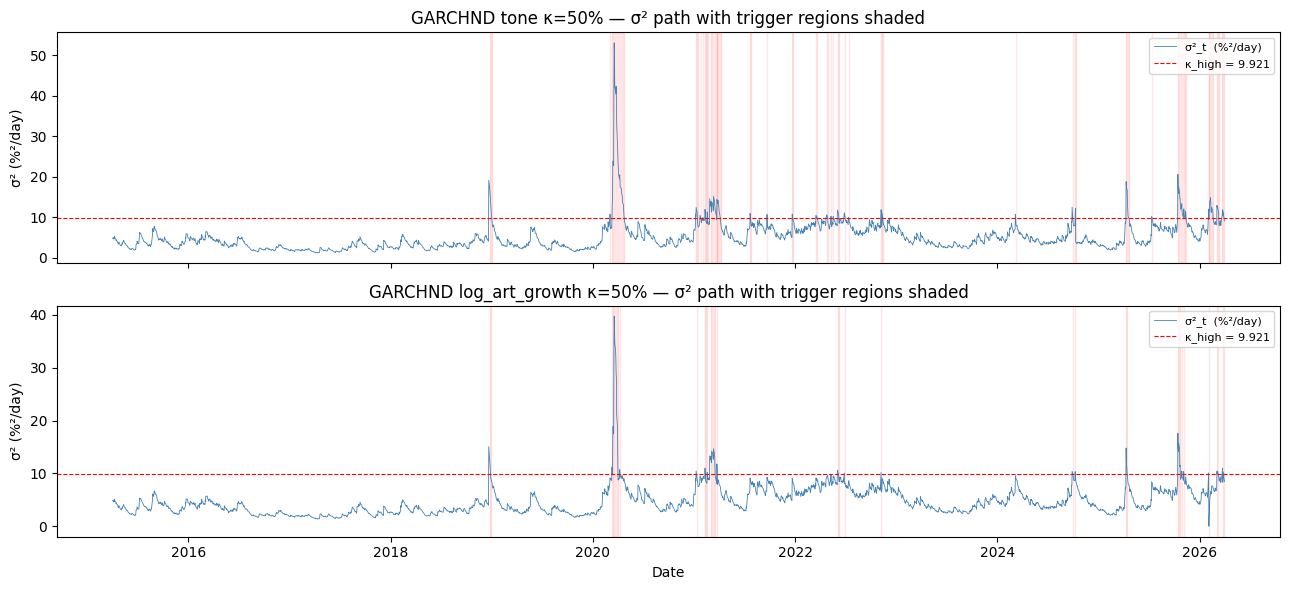

In [37]:
GAP_DAYS = 5

def episode_clusters(sig2_path, kappa, gap=GAP_DAYS):
    # σ²_{t-1} ≥ κ_high activates d_3 at time t
    triggered = np.zeros(len(sig2_path), dtype=bool)
    triggered[1:] = sig2_path[:-1] >= kappa

    clusters = []
    in_run = False
    run_start = last_true = None
    for t, flag in enumerate(triggered):
        if flag:
            if not in_run:
                run_start = t
                in_run = True
            last_true = t
        else:
            if in_run and (t - last_true) > gap:
                clusters.append((run_start, last_true))
                in_run = False
    if in_run:
        clusters.append((run_start, last_true))
    return clusters, triggered

def summarize_clusters(clusters, triggered, dates, label):
    n_days = int(triggered.sum())
    pct = 100*n_days/len(triggered)
    print(f'\n=== {label} ===')
    print(f'Total triggered days (σ²_{{t-1}} ≥ κ_high): {n_days} of {len(triggered)} ({pct:.2f}%)')
    print(f'Distinct episodes (gap ≤ {GAP_DAYS} days): {len(clusters)}')
    if not clusters:
        return []
    sorted_cl = sorted(clusters, key=lambda c: c[1]-c[0], reverse=True)[:10]
    print(f'Top 10 longest episodes:')
    print(f'  {"#":<4}{"start":<14}{"end":<14}{"days":>6}')
    for i, (s, e) in enumerate(sorted_cl, 1):
        print(f'  {i:<4}{str(dates[s].date()):<14}{str(dates[e].date()):<14}{e-s+1:>6}')
    longest = sorted_cl[0][1] - sorted_cl[0][0] + 1
    print(f'\n  → Block-bootstrap block length recommendation: ≥ {longest} days '
          f'(longest episode).')
    print(f'  → HAC bandwidth recommendation: ≥ {max(longest, 22)} lags.')
    if len(clusters) <= 5:
        print(f'  VERDICT: only {len(clusters)} episodes — i.i.d. t-stats overstate evidence.')
    return sorted_cl

clusters_tone, trig_tone = episode_clusters(sig2_tone, KAPPA_HIGH)
clusters_artg, trig_artg = episode_clusters(sig2_artg, KAPPA_HIGH)

top_tone = summarize_clusters(clusters_tone, trig_tone, df.index, 'GARCHND κ=50% tone')
top_artg = summarize_clusters(clusters_artg, trig_artg, df.index, 'GARCHND κ=50% log_art_growth')

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for ax, sig2, trig, label in [(axes[0], sig2_tone, trig_tone, 'GARCHND tone'),
                                (axes[1], sig2_artg, trig_artg, 'GARCHND log_art_growth')]:
    ax.plot(df.index, sig2, color='steelblue', lw=0.6, label='σ²_t  (%²/day)')
    ax.axhline(KAPPA_HIGH, color='red', lw=0.8, linestyle='--',
                label=f'κ_high = {KAPPA_HIGH:.3f}')
    # Shade triggered regions
    in_trig = False; t0 = None
    for t, fl in enumerate(trig):
        if fl and not in_trig:
            t0 = t; in_trig = True
        elif not fl and in_trig:
            ax.axvspan(df.index[t0], df.index[t-1], color='red', alpha=0.10)
            in_trig = False
    if in_trig:
        ax.axvspan(df.index[t0], df.index[-1], color='red', alpha=0.10)
    ax.set_title(f'{label} κ=50% — σ² path with trigger regions shaded')
    ax.set_ylabel('σ² (%²/day)')
    ax.legend(loc='upper right', fontsize=8)
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## Check 5 — Lead-lag cross-correlation (news vs realized volatility)

Model-free test of the maintained hypothesis behind the whole thesis: does news *lead*
volatility, or merely move with it / lag it? For each news series $x$ and log realized
variance $\ln RV^{rs}_t$ we compute the sample cross-correlation

$$\rho_x(k) = \mathrm{Corr}\!\left(x_{t+k},\ \ln RV_t\right), \qquad k = -10,\dots,+10.$$

With this sign convention **$k<0$ means $x$ leads $RV$** (past news vs current volatility)
and $k>0$ means $RV$ leads news. The 1-day lead $k=-1$ is the exact analogue of the
$\gamma\, d_3\, x^2_{t-1}$ term in the GARCHND variance equation.

Series: signed `tone` (leverage/asymmetry channel), news intensity `|tone|` (maps to the
model's $x^2$ term), and `log_art_growth` (news volume). Two panels per series:

- **Raw CCF** with the white-noise band $\pm 1.96/\sqrt N$. Both series are strongly
  autocorrelated (RV especially), so this band is *anti-conservative* — it over-flags.
  Shown for the picture only.
- **Prewhitened CCF** (Box–Jenkins): fit an AR($p^*$) to the input $x$ (order by AIC),
  apply that *same* filter to both $x$ and $\ln RV$, then cross-correlate the residuals.
  Once $x$ is whitened the band $\pm 1.96/\sqrt N$ is *valid* — this is the panel the
  conclusion rests on.

**Reading**: significant prewhitened $\rho_x(k)$ at $k<0$ ⇒ news carries incremental,
forward-looking information about volatility (supports the §5.7 interpretation). Mass only
at $k\ge 0$ ⇒ news lags volatility (attention follows moves, reverse timing).

=== ρ(k) = Corr(x_{t+k}, ln RV_t)   |   k<0 ⇒ news LEADS RV ===
Raw white-noise band ±0.037  (anti-conservative; use the _pw columns)

 lag  tone_raw  tone_pw  |tone|_raw  |tone|_pw  artg_raw  artg_pw
 -10     0.022    0.023       0.005      0.003    -0.009   -0.002
  -9    -0.003   -0.005       0.013      0.011     0.050    0.022
  -8     0.006    0.010      -0.001     -0.002    -0.033   -0.013
  -7    -0.004   -0.010       0.001     -0.001    -0.011    0.003
  -6     0.029    0.036       0.019      0.019     0.014    0.025
  -5    -0.023   -0.032       0.006      0.000     0.015    0.028
  -4     0.033    0.043       0.016      0.012    -0.005    0.017
  -3     0.007    0.014       0.018      0.019     0.030    0.034
  -2    -0.028   -0.026      -0.032     -0.040    -0.013    0.016
  -1    -0.031   -0.023      -0.012     -0.015    -0.017    0.002
   0    -0.027   -0.017       0.014      0.014     0.001    0.015
   1    -0.046   -0.040      -0.015     -0.019     0.031    0.029
   2   

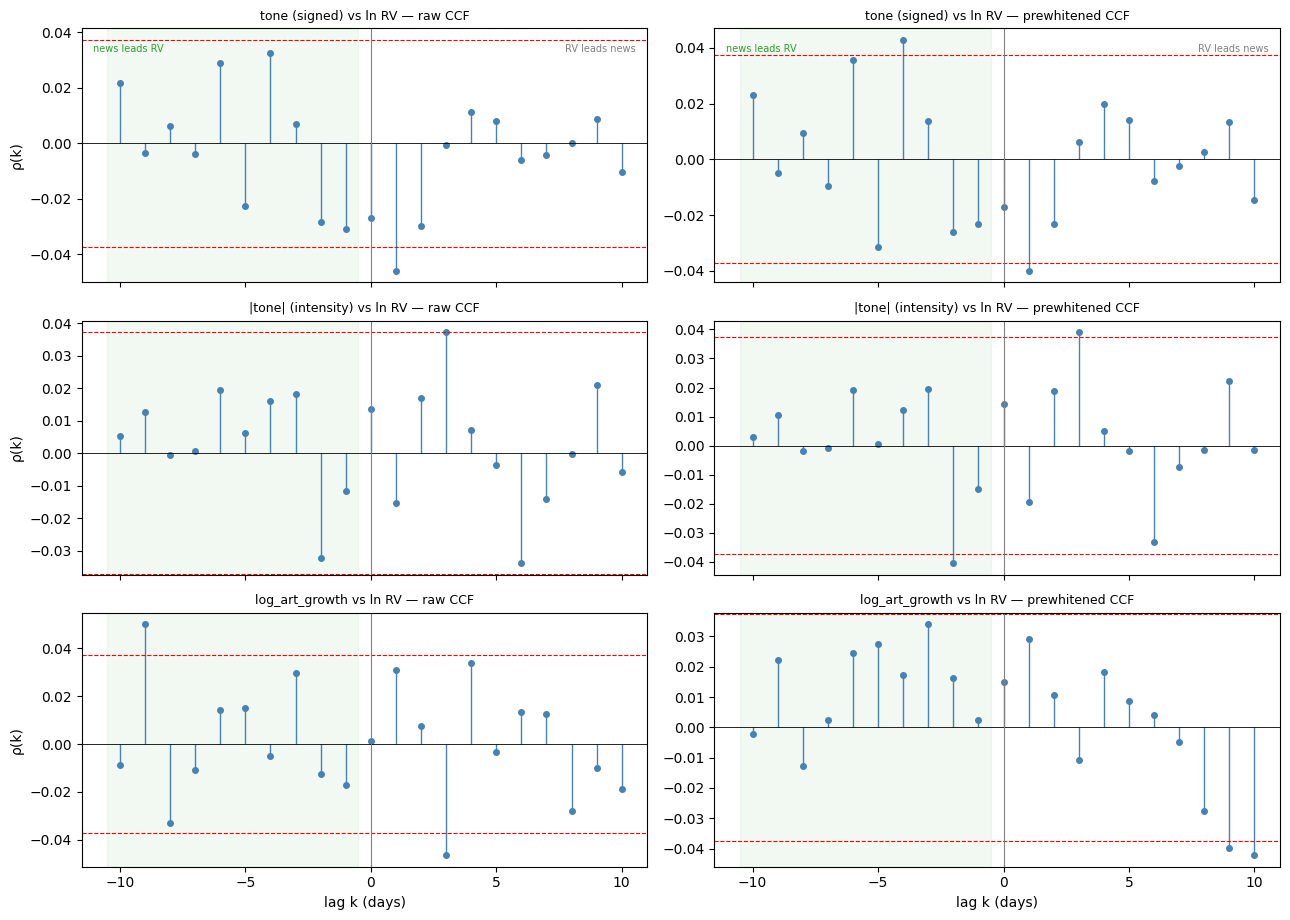

In [38]:
# ============================================================
# Check 5 — Lead-lag cross-correlation: news vs realized volatility
# ρ_x(k) = Corr(x_{t+k}, ln RV_t),  k = -10..+10.
#   k < 0  ⇒  x (news) LEADS RV   (forecasting-relevant side)
#   k > 0  ⇒  RV LEADS x
# Raw CCF (white-noise band, anti-conservative) + Box–Jenkins prewhitened CCF
# (valid band). Uses tone, log_artg, RV_pct2 from the first code cell.
# ============================================================
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import acorr_ljungbox

MAXLAG_CCF = 10
LAGS = list(range(-MAXLAG_CCF, MAXLAG_CCF + 1))

rv_log = np.log(np.clip(RV_pct2, 1e-8, None))   # log RV: robust to the COVID-era spikes

SERIES = {                       # display name -> series
    'tone (signed)':      tone,
    '|tone| (intensity)': np.abs(tone),
    'log_art_growth':     log_artg,
}
SHORT = {'tone (signed)': 'tone', '|tone| (intensity)': '|tone|',
         'log_art_growth': 'artg'}

def cross_corr(x, y, k):
    """ρ(k) = Corr(x_{t+k}, y_t).  k<0 ⇒ x leads y."""
    x = np.asarray(x, float); y = np.asarray(y, float); n = len(x)
    if k >= 0:
        xa, ya = x[k:], y[:n - k]
    else:
        m = -k; xa, ya = x[:n - m], y[m:]
    msk = ~(np.isnan(xa) | np.isnan(ya))
    xa, ya = xa[msk], ya[msk]
    if len(xa) < 3:
        return np.nan
    return float(np.corrcoef(xa, ya)[0, 1])

def ar_prewhiten(x, y, maxlag=10):
    """AR(p*) chosen on x by AIC (no trend, demeaned); apply the same (1-φ(L)) filter
       to x and y. Returns whitened x, filtered y, p*, and Ljung-Box(10) p on whitened x."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    xm, ym = x - x.mean(), y - y.mean()
    best = (1, np.inf, None)
    for p in range(1, maxlag + 1):
        res = AutoReg(xm, lags=p, trend='n').fit()
        if res.aic < best[1]:
            best = (p, res.aic, res)
    p, _, res = best
    phi, n = np.asarray(res.params), len(xm)          # phi = [φ1,...,φp]
    ax = np.array([xm[t] - sum(phi[i] * xm[t-1-i] for i in range(p)) for t in range(p, n)])
    ay = np.array([ym[t] - sum(phi[i] * ym[t-1-i] for i in range(p)) for t in range(p, n)])
    lb_p = float(acorr_ljungbox(ax, lags=[10], return_df=True)['lb_pvalue'].iloc[0])
    return ax, ay, p, lb_p

# ---- Compute raw and prewhitened CCFs ----
raw_ccf, pw_ccf, pw_p, pw_lb, band_pw = {}, {}, {}, {}, {}
band_raw = 1.96 / np.sqrt(len(rv_log))
for name, x in SERIES.items():
    raw_ccf[name] = {k: cross_corr(x, rv_log, k) for k in LAGS}
    ax, ay, p_sel, lb_p = ar_prewhiten(x, rv_log, MAXLAG_CCF)
    pw_ccf[name]  = {k: cross_corr(ax, ay, k) for k in LAGS}
    pw_p[name], pw_lb[name] = p_sel, lb_p
    band_pw[name] = 1.96 / np.sqrt(len(rv_log) - p_sel)

# ---- Table ----
tbl = pd.DataFrame({'lag': LAGS})
for name in SERIES:
    tbl[f'{SHORT[name]}_raw'] = [round(raw_ccf[name][k], 3) for k in LAGS]
    tbl[f'{SHORT[name]}_pw']  = [round(pw_ccf[name][k], 3) for k in LAGS]
print('=== ρ(k) = Corr(x_{t+k}, ln RV_t)   |   k<0 ⇒ news LEADS RV ===')
print(f'Raw white-noise band ±{band_raw:.3f}  (anti-conservative; use the _pw columns)\n')
print(tbl.to_string(index=False))

# ---- Prewhitened lead-side verdict (the valid test) ----
print('\n=== Prewhitened lead-lag verdict (valid ±1.96/√N band) ===')
for name in SERIES:
    bp = band_pw[name]
    sig_lead = [k for k in LAGS if k < 0 and abs(pw_ccf[name][k]) > bp]
    sig_lag  = [k for k in LAGS if k > 0 and abs(pw_ccf[name][k]) > bp]
    k_peak   = max((k for k in LAGS if k < 0), key=lambda k: abs(pw_ccf[name][k]))
    print(f'\n{name:<20}  AR(p*={pw_p[name]})  LB(10) p={pw_lb[name]:.2f}  band ±{bp:.3f}')
    print(f'   ρ(k=-1) = {pw_ccf[name][-1]:+.3f}   strongest lead k={k_peak:+d}: '
          f'{pw_ccf[name][k_peak]:+.3f}')
    print(f'   sig lead lags (news→RV): {sig_lead if sig_lead else "none"}')
    print(f'   sig lag  lags (RV→news): {sig_lag  if sig_lag  else "none"}')
    if sig_lead and (not sig_lag or len(sig_lead) >= len(sig_lag)):
        print('   → news LEADS RV: incremental forward-looking information (supports §5.7).')
    elif sig_lag and not sig_lead:
        print('   → news LAGS RV: reverse timing — attention follows volatility.')
    else:
        print('   → no clear lead-lag asymmetry.')

# ---- Figure: raw vs prewhitened CCF per series ----
fig, axes = plt.subplots(len(SERIES), 2, figsize=(13, 3.1 * len(SERIES)), sharex=True)
for row, name in enumerate(SERIES):
    for col, (kind, dvals, band) in enumerate(
            [('raw CCF', raw_ccf[name], band_raw),
             ('prewhitened CCF', pw_ccf[name], band_pw[name])]):
        ax = axes[row, col]
        ax.axvspan(-MAXLAG_CCF - 0.5, -0.5, color='tab:green', alpha=0.06)  # news-leads side
        ml, sl, _ = ax.stem(LAGS, [dvals[k] for k in LAGS], basefmt=' ')
        plt.setp(sl, color='steelblue', lw=1.0); plt.setp(ml, color='steelblue', ms=4)
        ax.axhline(band,  color='red', ls='--', lw=0.8)
        ax.axhline(-band, color='red', ls='--', lw=0.8)
        ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='grey', lw=0.8)
        ax.set_title(f'{name} vs ln RV — {kind}', fontsize=9)
        if col == 0:
            ax.set_ylabel('ρ(k)')
        if row == 0:
            ax.text(0.02, 0.94, 'news leads RV', transform=ax.transAxes,
                    fontsize=7, color='tab:green', ha='left', va='top')
            ax.text(0.98, 0.94, 'RV leads news', transform=ax.transAxes,
                    fontsize=7, color='grey', ha='right', va='top')
axes[-1, 0].set_xlabel('lag k (days)'); axes[-1, 1].set_xlabel('lag k (days)')
plt.tight_layout(); plt.show()
